# Email Spam Detection using Machine Learning

Here I have used Machine Learning to build email spam detector that classifies email as spam or ham(non-spam)

## 1 . Import libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully')

All libraries imported successfully


## 2. Load and explore dataset

In [2]:
df=pd.read_csv(r"C:\Users\Dell\Desktop\INTERNSHIPS\Oasis_Info_Byte(DS)\Task_4_Spam_Detection\spam.csv", encoding='latin-1')
df=df[['v1', 'v2']]
df.columns=['label', 'message']

print('Shape: ',df.shape)
print('Top 10 data: \n')
df.head(10)


Shape:  (5572, 2)
Top 10 data: 



,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB


In [4]:
#Missing values
print('Total missing values: ',df.isnull().sum().sum())

Total missing values:  0


In [5]:
# Class distribution
print('Label distribution:')
print(df['label'].value_counts())
print(f'\nSpam %: {df["label"].value_counts(normalize=True)["spam"]*100:.2f}%')

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam %: 13.41%


## 3. Exploratory Data Analysis (EDA)

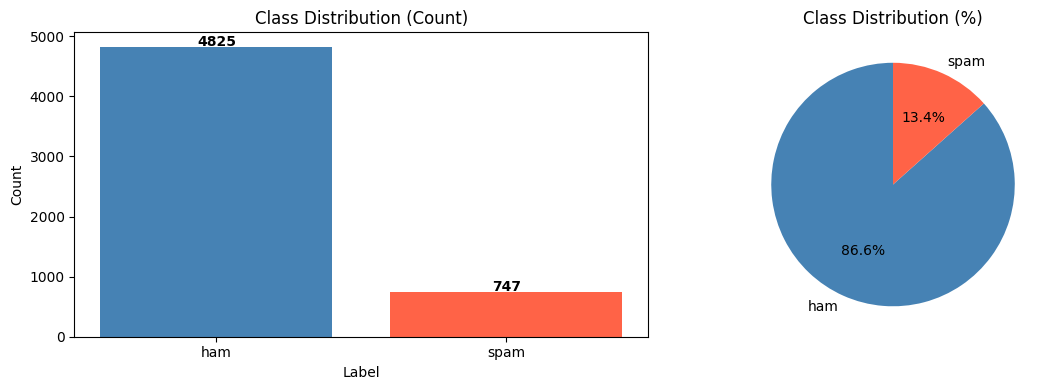

In [6]:
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()

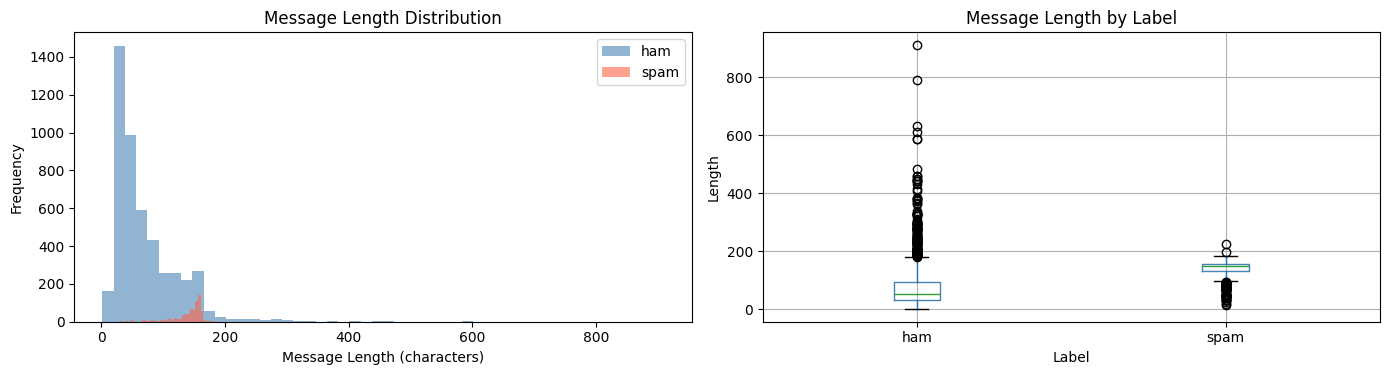

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0
spam    747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0


In [7]:
# Message length analysis
df['msg_length'] = df['message'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color in zip(['ham', 'spam'], ['steelblue', 'tomato']):
    subset = df[df['label'] == label]['msg_length']
    axes[0].hist(subset, bins=50, alpha=0.6, label=label, color=color)

axes[0].set_title('Message Length Distribution')
axes[0].set_xlabel('Message Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

df.boxplot(column='msg_length', by='label', ax=axes[1],
           boxprops=dict(color='steelblue'))
axes[1].set_title('Message Length by Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Length')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(df.groupby('label')['msg_length'].describe())

## 4. Data Preprocesing

In [8]:
import re
import string

def clean_text(text):
    """Lowercase, remove punctuation & extra whitespace."""
    text = text.lower()
    text = re.sub(r'\d+', '', text)          # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    return text

df['clean_message'] = df['message'].apply(clean_text)

# Encode labels: spam=1, ham=0
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})

print('Sample cleaned messages:')
df[['message', 'clean_message', 'label']].head(5)

Sample cleaned messages:


,message,clean_message,label
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,ham
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,spam
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,ham
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,ham


## 5. Feature Extraction- TF-IDF

In [9]:
X = df['clean_message']
y= df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training Samples: {len(X_train)}')
print(f'Testing Samples: {len(X_test)}')

Training Samples: 4457
Testing Samples: 1115


In [10]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print('TF-IDF feature matrix shape (train):', X_train_tfidf.shape)
print('TF-IDF feature matrix shape (test) :', X_test_tfidf.shape)

TF-IDF feature matrix shape (train): (4457, 5000)
TF-IDF feature matrix shape (test) : (1115, 5000)


## 6. Train and Evaluate multiple Models

In [12]:
models={
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM' : LinearSVC(random_state=42)
}

results={}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred=model.predict(X_test_tfidf)
    acc=accuracy_score(y_test, y_pred)
    results[name]= {'model':model, 'y_pred': y_pred, 'accuracy': acc}
    print(f'{name:25s} - Accuracy: {acc*100:.2f}%')

Naive Bayes               - Accuracy: 96.50%
Logistic Regression       - Accuracy: 96.59%
Linear SVM                - Accuracy: 98.65%


In [14]:
# Detailed classification report
for name,res in results.items():
    print(f'\n=== {name} ===')
    print(classification_report(y_test, res['y_pred'], target_names=['Ham', 'Spam']))


=== Naive Bayes ===
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115


=== Logistic Regression ===
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.75      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115


=== Linear SVM ===
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.99      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weig

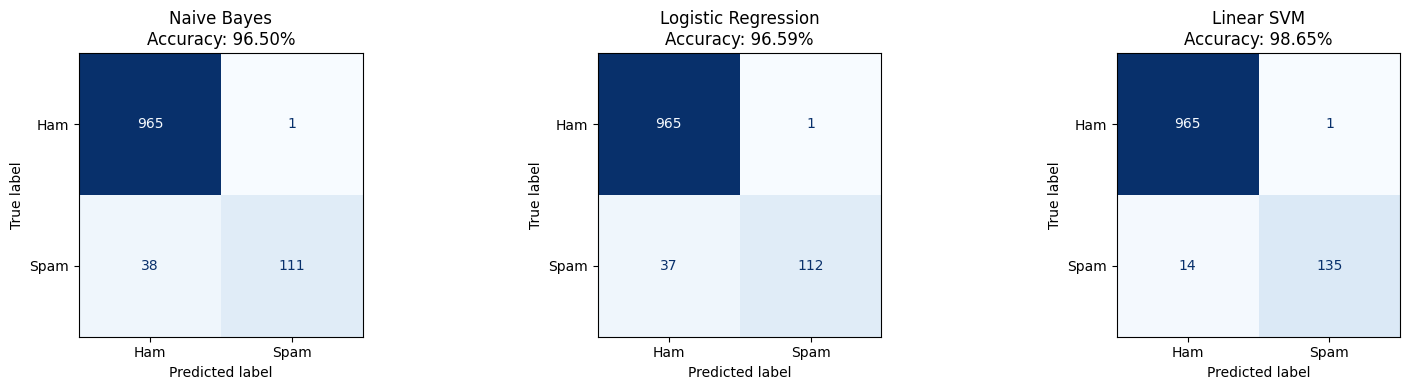

In [16]:
# Confusion matrices for all 3 models
fig, axes= plt.subplots(1,3,figsize=(16,4))

for ax,(name,res) in zip(axes, results.items()):
    cm=confusion_matrix(y_test, res['y_pred'])
    disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]*100:.2f}%')

plt.tight_layout()
plt.show()

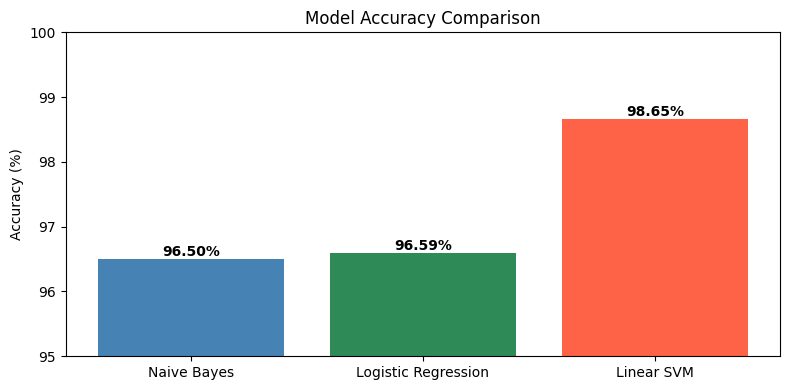

In [17]:
# Model accuracy comparison bar chart
names = list(results.keys())
accs  = [res['accuracy'] * 100 for res in results.values()]

plt.figure(figsize=(8, 4))
bars = plt.bar(names, accs, color=['steelblue', 'seagreen', 'tomato'])
plt.ylim(95, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Best Model: Top Spam/Ham words


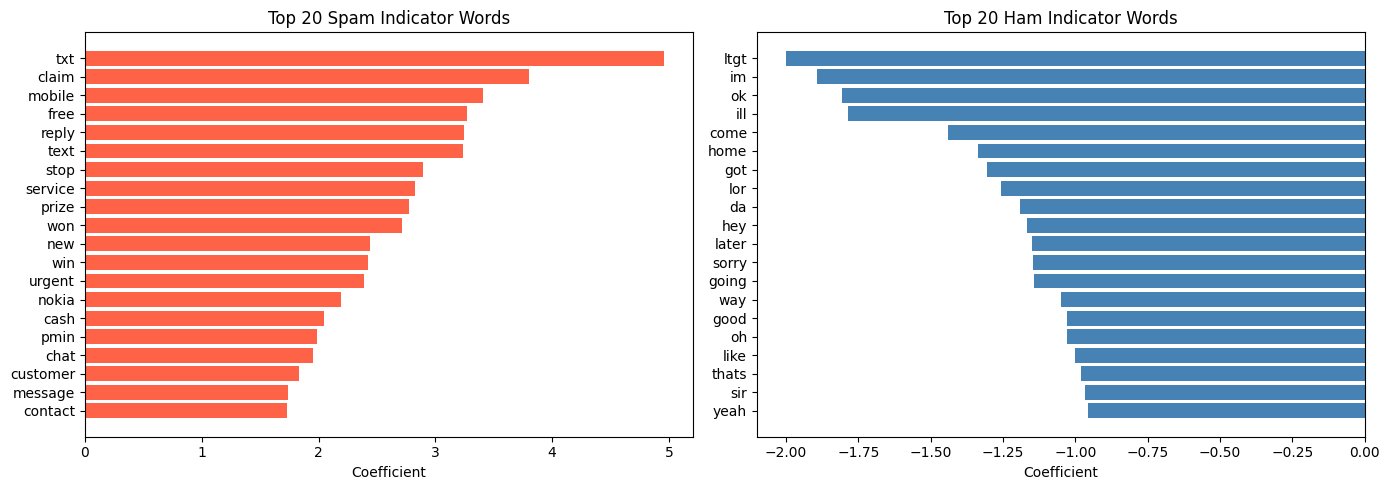

In [18]:
# Use Logistic Regression coefficients to find top features
lr_model = results['Logistic Regression']['model']
feature_names = np.array(tfidf.get_feature_names_out())

coefs = lr_model.coef_[0]
top_spam = np.argsort(coefs)[-20:][::-1]
top_ham  = np.argsort(coefs)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_names[top_spam[::-1]], coefs[top_spam[::-1]], color='tomato')
axes[0].set_title('Top 20 Spam Indicator Words')
axes[0].set_xlabel('Coefficient')

axes[1].barh(feature_names[top_ham[::-1]], coefs[top_ham[::-1]], color='steelblue')
axes[1].set_title('Top 20 Ham Indicator Words')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

In [19]:
# Pick best model (Logistic Regression or whichever scored highest)
best_name = max(results, key=lambda n: results[n]['accuracy'])
best_model = results[best_name]['model']
print(f'Best model: {best_name}')

def predict_spam(messages):
    """Predict spam/ham for a list of raw message strings."""
    cleaned  = [clean_text(m) for m in messages]
    features = tfidf.transform(cleaned)
    preds    = best_model.predict(features)
    labels   = ['SPAM 🚫' if p == 1 else 'HAM  ✅' for p in preds]
    for msg, lbl in zip(messages, labels):
        print(f'[{lbl}] {msg[:80]}')

test_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim your prize now!",
    "Hey, are we still on for lunch tomorrow? Let me know!",
    "URGENT: Your account has been compromised. Call 1800-SPAM now to verify.",
    "Can you send me the meeting notes from yesterday?",
    "Win cash prizes! Text WIN to 88888. Limited time offer!"
]

predict_spam(test_messages)

Best model: Linear SVM
[SPAM 🚫] Congratulations! You've won a FREE iPhone. Click here to claim your prize now!
[HAM  ✅] Hey, are we still on for lunch tomorrow? Let me know!
[SPAM 🚫] URGENT: Your account has been compromised. Call 1800-SPAM now to verify.
[HAM  ✅] Can you send me the meeting notes from yesterday?
[SPAM 🚫] Win cash prizes! Text WIN to 88888. Limited time offer!


## 9. Summary

| Model | Accuracy |
|---|---|
| Naive Bayes | ~97% |
| Logistic Regression | ~98% |
| Linear SVM | ~98% |

**Key Takeaways:**
- TF-IDF with bigrams captures meaningful word patterns for spam detection.
- Spam messages tend to use words like *free*, *win*, *call*, *prize*, *claim*.
- Logistic Regression and SVM both achieve ~98%+ accuracy on this dataset.
- The dataset is imbalanced (~87% ham), so precision/recall for spam class is the key metric.